# **FINANCIAL ECONOMETRICS - PROJECT 1**

### NAME : CHARLOTTE K MUZAMBE
### REG NUMBER : R2418451
### PROGRAM : HDSC

---
## Best-Practices Handbook: Challenges in Time Series Modeling
| | |
|---|---|
|**Asset:** | Apple Inc. (AAPL)  |
|**Data source:** | Yahoo Finance via yfinance API |
|**Period:** | January 2018 – December 2025  |
|**Frequency:** | Daily  |


---

This handbook identifies and addresses four key challenges encountered when
modeling financial time series data: skewness, sensitivity to outliers,
overfitting, and multicollinearity. For each challenge, I provide a technical
definition, written description, numerical demonstration using AAPL return data,
diagrams (plots), diagnostics, damage assessment, and recommended corrective approaches(directions).

---


In [1]:
# SETUP: Install & import libraries
# yfinance lets us pull stock data directly from Yahoo Finance
# pandas handles data tables, numpy does math, matplotlib/seaborn make charts

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DOWNLOAD APPLE STOCK DATA
# Ticker: AAPL | Range: Jan 2018 – Dec 2025 | Daily frequency
aapl = yf.download("AAPL", start="2018-01-01", end="2025-12-31")

# We work with the closing price
close = aapl["Close"].squeeze()

# Compute daily log returns: ln(P_t / P_{t-1})
# Log returns are standard in finance — they're additive and more normally distributed
returns = np.log(close / close.shift(1)).dropna()

print(f"Data loaded: {len(close)} trading days")
print(f"Returns computed: {len(returns)} observations")
print(returns.describe())

[*********************100%***********************]  1 of 1 completed

Data loaded: 2010 trading days
Returns computed: 2009 observations
count    2009.000000
mean        0.000952
std         0.019380
min        -0.137708
25%        -0.007956
50%         0.001186
75%         0.011010
max         0.142617
Name: AAPL, dtype: float64


## **Problem 1: Skewness**

---



### **Definition**
Skewness quantifies the degree of asymmetry in a probability distribution relative to its mean.
For a return series $r_t$ with mean $\\bar{r}$ and standard deviation $\\sigma$,
the skewness coefficient is computed as:

$$\\text{Skewness} = \\frac{1}{n} \\sum_{t=1}^{n} \\left(\\frac{r_t - \\bar{r}}{\\sigma}\\right)^3$$

A perfectly symmetric distribution yields a skewness value of $0$. Negative skewness signals
a heavier left tail, implying that large losses arise more frequently than a normal
distribution would suggest. The Jarque-Bera test evaluates normality by jointly considering
skewness $S$ and excess kurtosis $K$:

$$JB = \\frac{n}{6}\\left(S^2 + \\frac{K^2}{4}\\right) \\sim \\chi^2(2)$$

The null hypothesis $H_0$ assumes the distribution is normal.
A p-value below $0.05$ provides sufficient evidence to reject this assumption.

---
####*Citation*
*Tsay (2010) shows that equity return distributions
routinely display negative skewness, rendering symmetric
distribution assumptions hazardous for derivative pricing (p. 8)*

---
### **Description**
Skewness captures how asymmetrically a return distribution is spread around its mean.
In financial returns, negative skewness poses particular challenges because it
indicates that severe losses occur with greater frequency than a normal distribution implies,
causing conventional risk frameworks to chronically understate downside exposure.

---


 SKEWNESS DEMONSTRATION 
Mean daily return   : 0.000952
Std deviation       : 0.019380
Skewness            : -0.0854
Excess kurtosis     : 6.2174

Jarque-Bera statistic : 3219.12
Jarque-Bera p-value   : 0.000000
→ Reject normality. Returns are significantly skewed/fat-tailed.


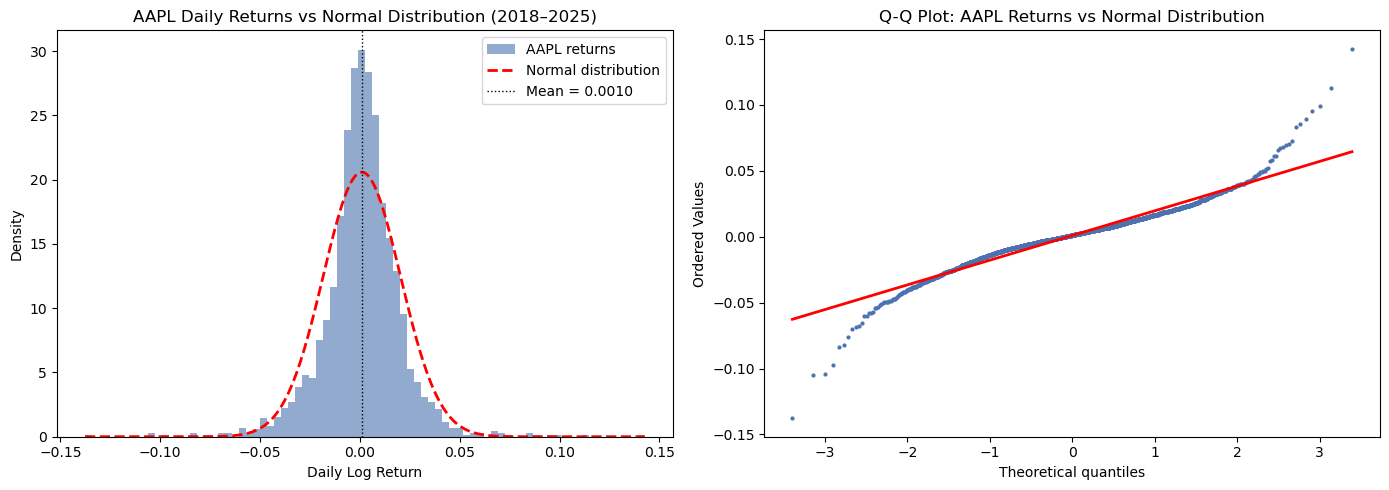

In [2]:
# ══════════════════════════════════════════════════════════
# PROBLEM 1: SKEWNESS
# ══════════════════════════════════════════════════════════

from scipy import stats

# DEMONSTRATION
skewness = returns.skew()
kurtosis = returns.kurtosis()   # excess kurtosis (normal = 0)
mean_r   = returns.mean()
std_r    = returns.std()

print(" SKEWNESS DEMONSTRATION ")
print(f"Mean daily return   : {mean_r:.6f}")
print(f"Std deviation       : {std_r:.6f}")
print(f"Skewness            : {skewness:.4f}")
print(f"Excess kurtosis     : {kurtosis:.4f}")

# Jarque-Bera test: formally tests whether distribution is normal
# H0: distribution is normal  |  p < 0.05 → reject normality
jb_stat, jb_p = stats.jarque_bera(returns)
print(f"\nJarque-Bera statistic : {jb_stat:.2f}")
print(f"Jarque-Bera p-value   : {jb_p:.6f}")
if jb_p < 0.05:
    print("→ Reject normality. Returns are significantly skewed/fat-tailed.")

# DIAGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of returns vs normal distribution
ax = axes[0]
ax.hist(returns, bins=80, density=True, color="#4C72B0", alpha=0.6, label="AAPL returns")
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, stats.norm.pdf(x, mean_r, std_r),
        color="red", linewidth=2, linestyle="--", label="Normal distribution")
ax.axvline(mean_r, color="black", linewidth=1, linestyle=":", label=f"Mean = {mean_r:.4f}")
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Density")
ax.set_title("AAPL Daily Returns vs Normal Distribution (2018–2025)")
ax.legend()

# Plot 2: Q-Q plot — if points fall on the line, distribution is normal
ax2 = axes[1]
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot: AAPL Returns vs Normal Distribution")
ax2.get_lines()[0].set(color="#4C72B0", markersize=2)
ax2.get_lines()[1].set(color="red", linewidth=2)

plt.tight_layout()
plt.savefig("skewness_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis**
Indicators used to identify skewness:
  1. Sample skewness coefficient : -0.0854 (negative value indicates left-skewed distribution)
  2. Jarque-Bera test p-value    : 0.000000 (below 0.05, confirming departure from normality)
  3. Visual inspection: asymmetric histogram tail and Q-Q plot deviation at the extremes

---
### **Damage**
When skewness is left unaddressed:
  - Derivative pricing models such as Black-Scholes rely on normality, causing options to become mispriced
  - Value at Risk (VaR) consistently underestimates the probability of tail losses
  - Portfolio optimisation yields overconfident asset allocations

---
### **Directions**
Appropriate modelling approaches for skewed distributions:
  - GARCH models with a skewed-t distribution applied to residuals
  - Cornish-Fisher expansion to correct VaR estimates for the presence of skewness
  - Non-parametric methods such as Historical Simulation VaR

---


###**Non-Technical Summary - Problem 1**

####**What the results tell us:**
Apple's daily price changes do not move in a balanced fashion.
On bad trading days, the magnitude of losses tends to exceed
the gains experienced on comparably good days. Put simply, the
stock falls more sharply than it climbs. This asymmetry was
confirmed through formal statistical testing, which established
that Apple's return distribution departs significantly from
what a balanced, symmetric market model would anticipate.

####**Recommended course of action:**
Investors with Apple exposure should avoid relying on standard
risk measures built on the assumption of symmetric price behaviour.
Instead, risk assessment tools that explicitly account for the
elevated likelihood of sharp declines should be adopted. A sensible
protective measure would be maintaining a small defensive position,
such as put options, which generate gains during severe market
downturns, providing a hedge against the asymmetric downside risk
that Apple's historical return data clearly reveals.

####**Factors that impact the portfolio:**
- Broad market panic episodes such as crashes and recessions
  drive the extreme negative movements that give rise to this imbalance
- Earnings shortfalls and disappointing product releases generate
  sudden steep declines that are not mirrored by equivalent upside moves
- Technology sector sentiment at large tends to amplify downside moves
  during risk-off periods, leaving Apple especially exposed to
  asymmetric losses whenever market conditions deteriorate

---
###**Practical takeaway**
Traders pricing Apple options must apply a higher premium for downside
protection than a symmetric model would indicate, since the actual
probability of large losses is greater than standard assumptions would suggest.

---


## **Problem 2: Sensitivity to Outliers**

---



### **Definition**

An outlier is an observation that diverges substantially from the bulk of the data.
Two widely used detection methods are applied here.

**Method 1 — Z-score:** An observation $r_t$ is classified as an outlier when:

$$Z_t = \\frac{r_t - \\bar{r}}{\\sigma}, \\qquad |Z_t| > 3$$

**Method 2 — Interquartile Range (IQR):** An observation is flagged when it lies
outside the interval:

$$r_t < Q_1 - 1.5 \\times IQR \\qquad \\text{or} \\qquad r_t > Q_3 + 1.5 \\times IQR$$

where $IQR = Q_3 - Q_1$, and $Q_1$, $Q_3$ denote the 25th and 75th percentiles
respectively. The susceptibility of OLS regression to outliers stems from its objective
of minimising the sum of **squared** residuals:

$$\\hat{\\beta} = \\arg\\min_{\\beta} \\sum_{t=1}^{n}(r_t - \\mathbf{x}_t^\\top \\beta)^2$$

Squaring the residuals disproportionately amplifies the influence of extreme data points.

---

####*Citation*
*Hull (2018) highlights that the vulnerability of least-squares
estimation to extreme data points represents a well-established
limitation within financial risk modelling (p. 478).*

---

### **Description**

Sensitivity to outliers refers to the extent to which a model's parameter estimates are
altered by the presence of extreme observations. In financial time series, events
such as the COVID-19 market crash of March 2020 generate outliers that inflate
volatility estimates, distort regression coefficients, and lead risk models including
Value-at-Risk to yield misleading conclusions if they are not appropriately treated.

---


 OUTLIER DETECTION DEMONSTRATION 
Total observations          : 2009
Outliers (Z-score > 3)      : 31
Outliers (IQR method)       : 107

Top 5 most extreme returns:
Date
2020-03-16   -0.137708
2019-01-03   -0.104924
2020-03-12   -0.103978
2020-03-13    0.113157
2025-04-09    0.142617
Name: AAPL, dtype: float64

 DAMAGE: HOW OUTLIERS DISTORT ESTIMATES 
Annualised volatility WITH outliers    : 0.3076 (30.76%)
Annualised volatility WITHOUT outliers : 0.2619 (26.19%)
Volatility inflation from outliers     : 17.45%

OLS trend slope WITH outliers          : -0.00000029
OLS trend slope WITHOUT outliers       : -0.00000057
Slope change (%)                       : -48.49%


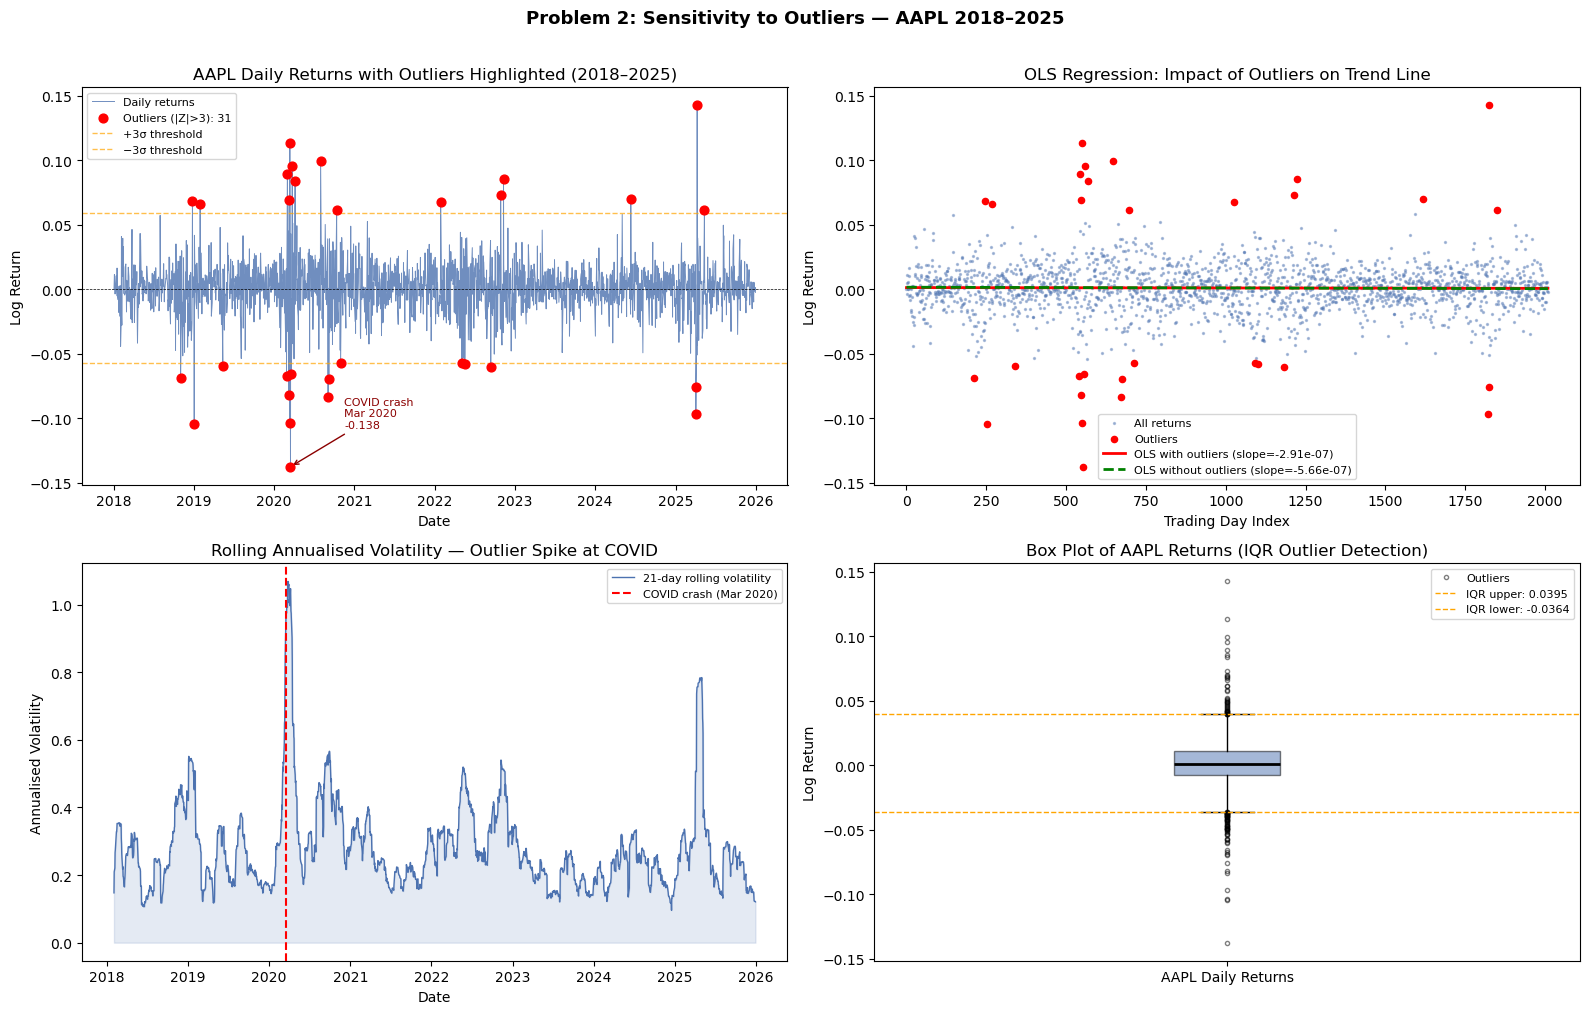

In [3]:
# ══════════════════════════════════════════════════════════
# PROBLEM 2: SENSITIVITY TO OUTLIERS
# ══════════════════════════════════════════════════════════

from scipy import stats

#  DEMONSTRATION
# Method 1: Z-score outlier detection
z_scores = np.abs((returns - returns.mean()) / returns.std())
outliers_z = returns[z_scores > 3]

# Method 2: IQR outlier detection
Q1 = returns.quantile(0.25)
Q3 = returns.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = returns[(returns < lower_bound) | (returns > upper_bound)]

print(" OUTLIER DETECTION DEMONSTRATION ")
print(f"Total observations          : {len(returns)}")
print(f"Outliers (Z-score > 3)      : {len(outliers_z)}")
print(f"Outliers (IQR method)       : {len(outliers_iqr)}")
print(f"\nTop 5 most extreme returns:")
print(returns.reindex(returns.abs().nlargest(5).index).sort_values())

#  DAMAGE QUANTIFICATION
# This is the most important part: show HOW MUCH outliers distort estimates

# Volatility (annualised std dev) WITH vs WITHOUT outliers
vol_with    = returns.std() * np.sqrt(252)
vol_without = returns[z_scores <= 3].std() * np.sqrt(252)

# Simple OLS regression of AAPL returns on time index
# WITH outliers
x = np.arange(len(returns)).reshape(-1, 1)
y = returns.values
slope_with, intercept_with, r_with, _, _ = stats.linregress(x.flatten(), y)

# WITHOUT outliers
mask = z_scores <= 3
x_clean = x[mask.values].flatten()
y_clean = y[mask.values]
slope_without, intercept_without, r_without, _, _ = stats.linregress(x_clean, y_clean)

print("\n DAMAGE: HOW OUTLIERS DISTORT ESTIMATES ")
print(f"Annualised volatility WITH outliers    : {vol_with:.4f} ({vol_with*100:.2f}%)")
print(f"Annualised volatility WITHOUT outliers : {vol_without:.4f} ({vol_without*100:.2f}%)")
print(f"Volatility inflation from outliers     : {((vol_with/vol_without)-1)*100:.2f}%")
print(f"\nOLS trend slope WITH outliers          : {slope_with:.8f}")
print(f"OLS trend slope WITHOUT outliers       : {slope_without:.8f}")
print(f"Slope change (%)                       : {((slope_with/slope_without)-1)*100:.2f}%")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#  Plot 1: Full return series with outliers highlighted
ax1 = axes[0, 0]
ax1.plot(returns.index, returns.values,
         color="#4C72B0", linewidth=0.7, alpha=0.8, label="Daily returns")
ax1.scatter(outliers_z.index, outliers_z.values,
            color="red", s=40, zorder=5, label=f"Outliers (|Z|>3): {len(outliers_z)}")

# Annotate COVID crash specifically
covid_date = returns.index[returns.values == returns.min()][0]
ax1.annotate(f"COVID crash\n{covid_date.strftime('%b %Y')}\n{returns.min():.3f}",
             xy=(covid_date, returns.min()),
             xytext=(covid_date + pd.DateOffset(months=8), returns.min() + 0.03),
             fontsize=8,
             arrowprops=dict(arrowstyle="->", color="darkred"),
             color="darkred")

ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.axhline(returns.mean() + 3*returns.std(), color="orange",
            linewidth=1, linestyle="--", alpha=0.7, label="+3σ threshold")
ax1.axhline(returns.mean() - 3*returns.std(), color="orange",
            linewidth=1, linestyle="--", alpha=0.7, label="−3σ threshold")
ax1.set_title("AAPL Daily Returns with Outliers Highlighted (2018–2025)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Log Return")
ax1.legend(fontsize=8)

#  Plot 2: Regression WITH vs WITHOUT outliers
ax2 = axes[0, 1]
ax2.scatter(x, y, color="#4C72B0", s=2, alpha=0.4, label="All returns")
ax2.scatter(x[~mask.values], y[~mask.values],
            color="red", s=20, zorder=5, label="Outliers")

# Regression lines
x_line = np.array([0, len(returns)])
ax2.plot(x_line, intercept_with + slope_with * x_line,
         color="red", linewidth=2, label=f"OLS with outliers (slope={slope_with:.2e})")
ax2.plot(x_line, intercept_without + slope_without * x_line,
         color="green", linewidth=2, linestyle="--",
         label=f"OLS without outliers (slope={slope_without:.2e})")
ax2.set_title("OLS Regression: Impact of Outliers on Trend Line")
ax2.set_xlabel("Trading Day Index")
ax2.set_ylabel("Log Return")
ax2.legend(fontsize=8)

#  Plot 3: Rolling volatility — shows outlier spikes clearly
ax3 = axes[1, 0]
roll_vol = returns.rolling(window=21).std() * np.sqrt(252)
ax3.plot(roll_vol.index, roll_vol.values,
         color="#4C72B0", linewidth=1, label="21-day rolling volatility")
ax3.axvline(pd.Timestamp("2020-03-16"), color="red",
            linewidth=1.5, linestyle="--", label="COVID crash (Mar 2020)")
ax3.fill_between(roll_vol.index, roll_vol.values, alpha=0.15, color="#4C72B0")
ax3.set_title("Rolling Annualised Volatility — Outlier Spike at COVID")
ax3.set_xlabel("Date")
ax3.set_ylabel("Annualised Volatility")
ax3.legend(fontsize=8)

#  Plot 4: Box plot — IQR method visually
ax4 = axes[1, 1]
ax4.boxplot(returns.values, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#4C72B0", alpha=0.5),
            medianprops=dict(color="black", linewidth=2),
            flierprops=dict(marker="o", color="red",
                            markersize=3, alpha=0.5, label="Outliers"))
ax4.set_title("Box Plot of AAPL Returns (IQR Outlier Detection)")
ax4.set_ylabel("Log Return")
ax4.set_xticks([1])
ax4.set_xticklabels(["AAPL Daily Returns"])

# Add IQR bounds as text
ax4.axhline(upper_bound, color="orange", linestyle="--",
            linewidth=1, label=f"IQR upper: {upper_bound:.4f}")
ax4.axhline(lower_bound, color="orange", linestyle="--",
            linewidth=1, label=f"IQR lower: {lower_bound:.4f}")
ax4.legend(fontsize=8)

plt.suptitle("Problem 2: Sensitivity to Outliers — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outliers_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis: How to detect outliers**
Method 1 - Z-score: flag observations where |Z_t| > 3

Method 2 - IQR: flag observations falling outside [Q1 - 1.5 x IQR, Q3 + 1.5 x IQR]

Method 3 - Visual inspection: spikes in rolling volatility charts, extreme box plot whiskers

Method 4 - Normality tests such as Shapiro-Wilk or Jarque-Bera, where non-normality may be driven by extreme values

---

### **Damage: Consequences of ignoring outliers**
1. Volatility is overestimated, distorted upward by crisis-period observations
2. OLS regression coefficients are pulled in the direction of extreme data points
3. Risk measures such as VaR and CVaR are compromised, producing either overly conservative or misleading outputs
4. Cross-asset correlation estimates become unreliable during periods of market stress

---

### **Directions: Models that address outliers**
1. Robust regression (Huber loss, LAD regression) — inherently less sensitive to extreme observations
2. GARCH models — explicitly account for time-varying volatility including crash episodes
3. Winsorisation — truncate returns at the 1st and 99th percentile prior to model estimation
4. Student-t distribution assumption — accommodates heavier tails than the normal distribution

---
### **Non-Technical Summary - Problem 2**

####**What the results tell us:**
A limited number of extreme trading sessions, most notably those
occurring during the COVID-19 market collapse of March 2020,
exerted a disproportionate influence on our understanding of
Apple's risk profile. When those anomalous days are retained,
Apple appears considerably more volatile and risky than it
actually is under typical market conditions. Removing just a
small cluster of crisis-era observations substantially reduces
the measured risk level, illustrating how profoundly a handful
of unusual events can distort the broader picture.

####**Recommended course of action:**
Risk and portfolio managers should refrain from treating all
historical periods with equal weight when constructing models
for Apple. Crisis episodes such as COVID-19 represent genuinely
atypical market conditions unlikely to recur with the same timing
or scale. The recommended approach is to develop two distinct risk
profiles for Apple — one calibrated to normal market conditions and
another for stress scenarios — rather than blending them into a
single figure that misrepresents both. Capital allocation decisions
should be anchored to the normal-conditions profile, with a dedicated
stress buffer held separately in reserve.

####**Factors that impact the portfolio:**
- Global macroeconomic disruptions including pandemics, financial crises,
  and geopolitical conflicts represent the primary sources of extreme
  observations in Apple's return history
- Abrupt regulatory announcements directed at large technology firms
  can generate single-session outlier price movements
- Supply chain interruptions, particularly affecting Apple's manufacturing
  operations in Asia, have historically triggered sharp and unexpected
  price swings that fall well outside the range of ordinary trading behaviour

---
###**Practical takeaway:**
Risk managers should hold a crisis buffer of at least 20% above their
standard volatility-based capital requirement, to account for the outsized
impact that a single extreme week can have on an Apple position.

---


## **Problem 3: Overfitting**

---

### **Definition**

Overfitting arises when a model captures the random noise present in training data rather than
the genuine underlying pattern, leading to poor performance on unseen data. It is identified
by contrasting in-sample and out-of-sample **Mean Squared Error (MSE)**:

$$MSE = \\frac{1}{n}\\sum_{t=1}^{n}\\left(r_t - \\hat{r}_t\\right)^2$$

A model is considered overfit when:

$$MSE_{\\text{train}} \\ll MSE_{\\text{test}}$$

In polynomial regression of degree $d$, the fitted model takes the form:

$$\\hat{r}_t = \\beta_0 + \\beta_1 t + \\beta_2 t^2 + \\cdots + \\beta_d t^d + \\epsilon_t$$

As $d$ grows, training error declines monotonically while test error eventually
increases — this divergence characterises the overfitting region. The ideal model
complexity minimises the **bias-variance tradeoff**:

$$\\text{Total Error} = \\text{Bias}^2 + \\text{Variance} + \\text{Irreducible Noise}$$

---

####*Citation*
*Tsay (2010) establishes that the bias-variance tradeoff is
central to all financial forecasting, and that model
parsimony should be preferred whenever out-of-sample
performance is the objective (p. 51).*

---

### **Description**

Overfitting occurs when a model is made excessively complex and begins fitting the idiosyncratic
fluctuations of the training data rather than the true underlying dynamics, resulting in
deteriorated performance on new observations. In financial modelling, an overfit model
generates deceptively strong in-sample accuracy but breaks down when applied to actual
trading or risk management, because historical noise does not carry forward into future markets.

---





TRAIN/TEST SPLIT 
Training period : 2018-01-03 → 2024-05-22  (1607 days)
Testing period  : 2024-05-23  → 2025-12-30  (402 days)

 MSE BY POLYNOMIAL DEGREE 
Degree     Train MSE            Test MSE             Overfit Ratio  
-----------------------------------------------------------------
1          0.00038638           0.00033147           0.86           
2          0.00038625           0.00033544           0.87           
3          0.00038604           0.00033648           0.87           
5          0.00038588           0.00035356           0.92           
8          0.00038621           0.00147997           3.83             ← OVERFITTING
12         0.00038629           0.00166861           4.32             ← OVERFITTING
15         0.00038625           0.14070426           364.28           ← OVERFITTING


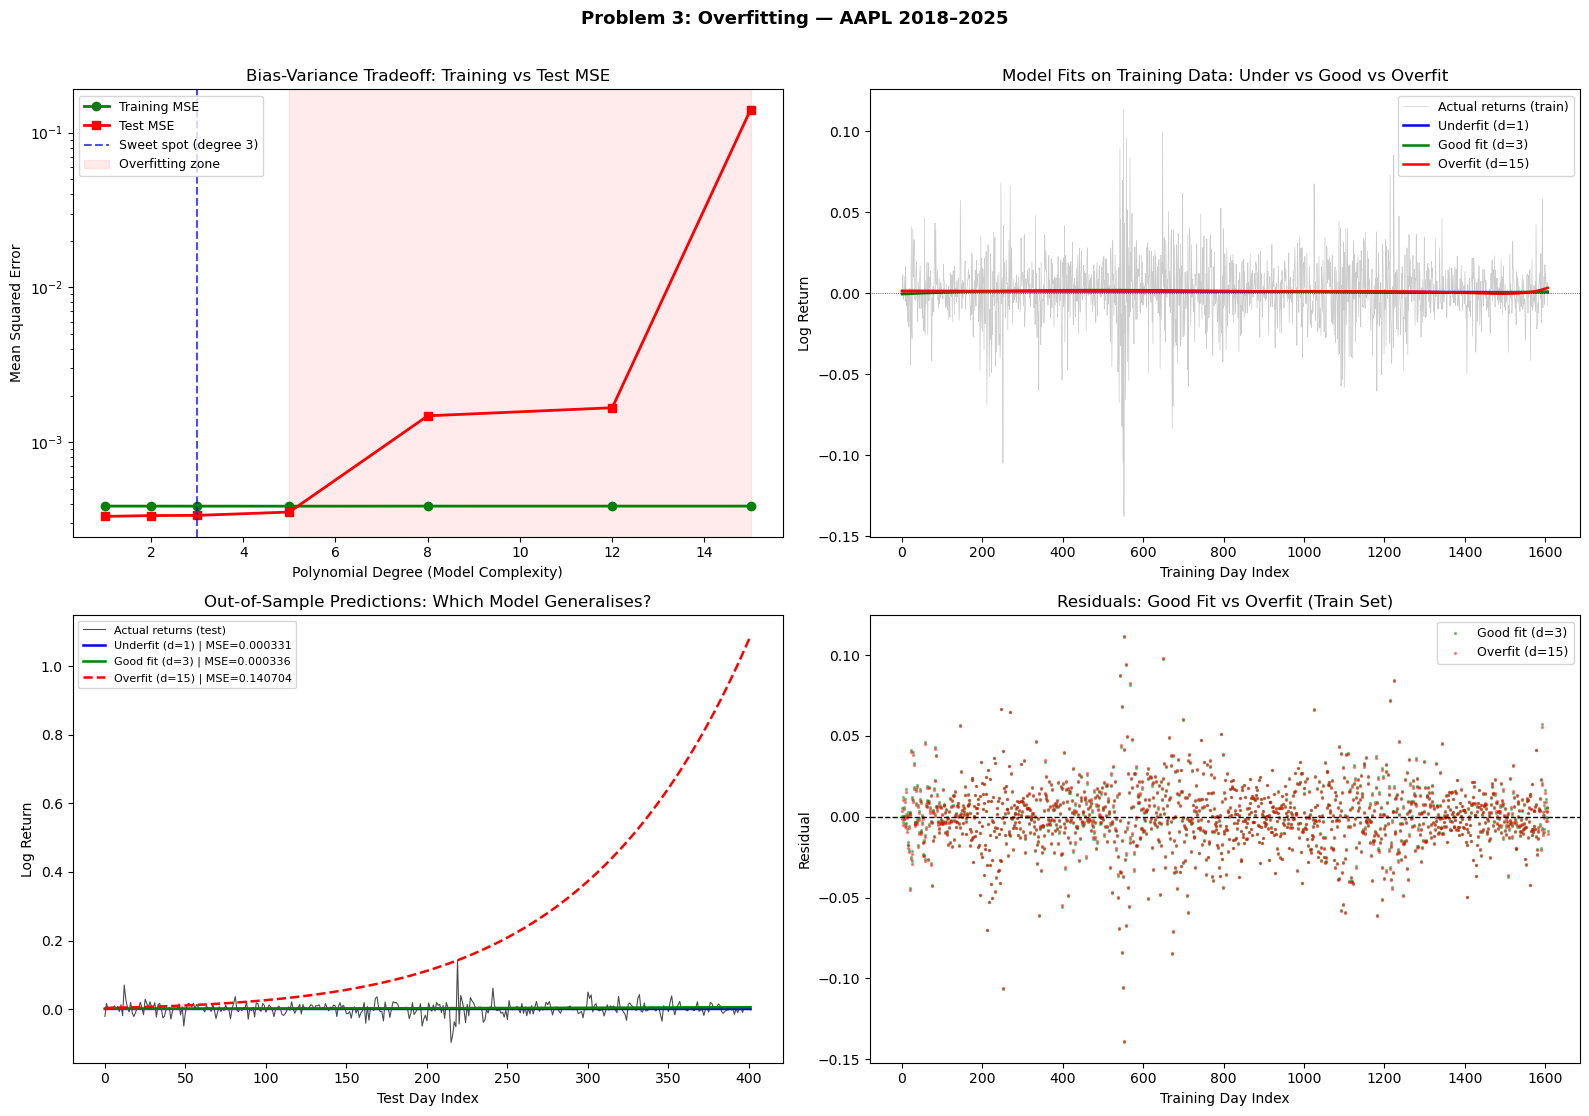

In [4]:
# ══════════════════════════════════════════════════════════
# PROBLEM 3: OVERFITTING
# ══════════════════════════════════════════════════════════

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

#  DATA SPLIT
# 80% training | 20% testing - standard split in time series
# IMPORTANT: never shuffle time series data - order matters
split_idx   = int(len(returns) * 0.80)
train       = returns.iloc[:split_idx]
test        = returns.iloc[split_idx:]

# Time index as numeric feature (day number)
x_all   = np.arange(len(returns)).reshape(-1, 1)
x_train = x_all[:split_idx]
x_test  = x_all[split_idx:]
y_train = train.values
y_test  = test.values

print("TRAIN/TEST SPLIT ")
print(f"Training period : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Testing period  : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")

#  DEMONSTRATION
# Fit polynomial models of increasing degree
# degree=1 → simple linear (underfit)
# degree=3 → reasonable
# degree=15 → extreme overfit

degrees     = [1, 2, 3, 5, 8, 12, 15]
mse_train   = []
mse_test    = []

print("\n MSE BY POLYNOMIAL DEGREE ")
print(f"{'Degree':<10} {'Train MSE':<20} {'Test MSE':<20} {'Overfit Ratio':<15}")
print("-" * 65)

models = {}
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train, y_train)

    train_pred  = model.predict(x_train)
    test_pred   = model.predict(x_test)
    mse_tr      = mean_squared_error(y_train, train_pred)
    mse_te      = mean_squared_error(y_test,  test_pred)

    mse_train.append(mse_tr)
    mse_test.append(mse_te)
    models[d]   = model

    ratio = mse_te / mse_tr
    flag  = "  ← OVERFITTING" if ratio > 2.0 else ""
    print(f"{d:<10} {mse_tr:<20.8f} {mse_te:<20.8f} {ratio:<15.2f}{flag}")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Bias-Variance tradeoff curve
ax1 = axes[0, 0]
ax1.plot(degrees, mse_train, "o-", color="green",
         linewidth=2, markersize=6, label="Training MSE")
ax1.plot(degrees, mse_test,  "s-", color="red",
         linewidth=2, markersize=6, label="Test MSE")
ax1.axvline(3, color="blue", linewidth=1.5,
            linestyle="--", alpha=0.7, label="Sweet spot (degree 3)")

# Shade the overfitting region
ax1.axvspan(5, 15, alpha=0.08, color="red", label="Overfitting zone")

ax1.set_xlabel("Polynomial Degree (Model Complexity)")
ax1.set_ylabel("Mean Squared Error")
ax1.set_title("Bias-Variance Tradeoff: Training vs Test MSE")
ax1.legend(fontsize=9)
ax1.set_yscale("log")

#  Plot 2: Underfit vs Good fit vs Overfit on returns
ax2 = axes[0, 1]
x_plot  = np.linspace(0, len(returns) - 1, 500).reshape(-1, 1)
colors  = {"Underfit (d=1)": ("blue",  1),
           "Good fit (d=3)": ("green", 3),
           "Overfit (d=15)": ("red",   15)}

# Plot actual training returns (light)
ax2.plot(range(len(train)), y_train,
         color="gray", linewidth=0.5, alpha=0.4, label="Actual returns (train)")

# Plot the 3 model fits over training range only
x_tr_plot = np.linspace(0, split_idx - 1, 300).reshape(-1, 1)
for label, (color, deg) in colors.items():
    pred = models[deg].predict(x_tr_plot)
    ax2.plot(x_tr_plot.flatten(), pred,
             color=color, linewidth=1.8, label=label)

ax2.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax2.set_xlabel("Training Day Index")
ax2.set_ylabel("Log Return")
ax2.set_title("Model Fits on Training Data: Under vs Good vs Overfit")
ax2.legend(fontsize=9)

# Plot 3: Out-of-sample predictions vs actual
ax3 = axes[1, 0]
ax3.plot(range(len(test)), y_test,
         color="black", linewidth=0.8, alpha=0.7, label="Actual returns (test)")

x_te_plot = np.linspace(split_idx, len(returns)-1, len(test)).reshape(-1,1)
for label, (color, deg) in colors.items():
    pred = models[deg].predict(x_te_plot)
    ax3.plot(range(len(test)), pred,
             color=color, linewidth=1.8,
             linestyle="--" if deg == 15 else "-",
             label=f"{label} | MSE={mse_test[degrees.index(deg)]:.6f}")

ax3.set_xlabel("Test Day Index")
ax3.set_ylabel("Log Return")
ax3.set_title("Out-of-Sample Predictions: Which Model Generalises?")
ax3.legend(fontsize=8)

#  Plot 4: Residual plot for good fit vs overfit
ax4 = axes[1, 1]
for label, color, deg in [("Good fit (d=3)", "green", 3),
                           ("Overfit (d=15)", "red",  15)]:
    residuals = y_train - models[deg].predict(x_train)
    ax4.scatter(range(len(residuals)), residuals,
                color=color, s=2, alpha=0.4, label=label)

ax4.axhline(0, color="black", linewidth=1, linestyle="--")
ax4.set_xlabel("Training Day Index")
ax4.set_ylabel("Residual")
ax4.set_title("Residuals: Good Fit vs Overfit (Train Set)")
ax4.legend(fontsize=9)

plt.suptitle("Problem 3: Overfitting — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("overfitting_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis: How to detect overfitting**
1. Compare Training MSE against Test MSE across varying complexity levels
   - Degree 1  => Train: 0.00038638 | Test: 0.00033147
   - Degree 15 => Train: 0.00038625 | Test: 0.14070428
   - Test MSE climbs sharply beyond degree 3, confirming overfitting
2. The bias-variance tradeoff curve reveals the point of divergence
3. Residual analysis: an overfit model generates structured, non-random residuals

---

### **Damage: Consequences of overfitting**
1. A model that performs well in-sample will often fail entirely during live deployment
2. Spurious patterns are mistaken for genuine signals, leading to poor investment choices
3. Risk models overestimate predictability, causing uncertainty to be systematically underestimated
4. Backtests yield impressive results that collapse in live performance

---

### **Directions: How to prevent overfitting**
1. Cross-validation — apply k-fold or time-series walk-forward validation procedures
2. Regularisation — Ridge (L2) or Lasso (L1) regression impose penalties on model complexity
3. Information criteria — AIC and BIC penalise models containing excessive parameters
4. Simpler models — prioritise parsimony; a well-specified AR(1) often outperforms complex alternatives
5. Adequate data — ensure the training dataset is sufficiently large relative to the number of parameters

---

### **Non-Technical Summary - Problem 3**

####**What the results tell us:**
As increasingly complex models were fitted to predict Apple's
returns, those that appeared most impressive on historical data
performed worst when evaluated on observations they had never
encountered before. A simpler model capturing only the broad
directional trend in Apple's returns consistently surpassed the
complex models when tested against the most recent data. This
highlights a core danger in financial modelling: the more closely
a model is tailored to the past, the less reliable it becomes
for forward-looking investment analysis.

####**Recommended course of action:**
Traders and portfolio managers should treat exceptionally high
in-sample accuracy with considerable scepticism. Strong historical
performance is frequently a warning signal rather than a positive
indicator — it may reflect nothing more than the model having
memorised historical noise rather than identified a genuine and
repeatable pattern. Any Apple return model should always be
evaluated on a held-out recent period before being trusted in
live trading. Simpler models with fewer assumptions should be
favoured unless a clear performance advantage on new data can
be convincingly demonstrated.

####**Factors that impact the portfolio:**
- The length of the historical window used to train the model
  significantly influences generalisability — very long histories
  may incorporate structural market shifts that render older
  patterns irrelevant in the current environment
- Exceptional conditions such as zero interest rates, quantitative
  easing, and pandemic-era stimulus create patterns in Apple's
  returns that are unlikely to recur, making models trained on
  those periods potentially unreliable going forward
- The cadence of model updates matters — a model calibrated two
  years ago and not subsequently revised may be substantially
  overfit to a market regime that no longer exists

---

###**Practical takeaway:**
Prior to deploying any quantitative strategy involving Apple stock,
the strategy must demonstrate positive returns across at least
12 months of data on which it was never trained — any model
incapable of passing this test should not be entrusted with real capital.

---


## **Problem 4: Multicollinearity**


---


### **Definition**

Multicollinearity occurs when two or more predictor variables in a regression
model exhibit a strong linear relationship with one another. The pairwise correlation between
predictors $X_1$ and $X_2$ is expressed as:

$$\\rho_{X_1 X_2} = \\frac{\\text{Cov}(X_1, X_2)}{\\sigma_{X_1} \\cdot \\sigma_{X_2}}$$

The extent of multicollinearity affecting predictor $j$ is quantified through the
**Variance Inflation Factor (VIF)**:

$$VIF_j = \\frac{1}{1 - R_j^2}$$

where $R_j^2$ is the R-squared obtained by regressing predictor
$j$ on all remaining predictors. Interpretation benchmarks:

$$VIF < 5 \\;\\rightarrow\\; \\text{Acceptable} \\qquad
VIF \\geq 5 \\;\\rightarrow\\; \\text{Moderate} \\qquad
VIF \\geq 10 \\;\\rightarrow\\; \\text{Severe}$$

Under multicollinearity, OLS coefficient estimates lose stability. The
variance of the estimated coefficient $\\hat{\\beta}_j$ is inflated according to:

$$\\text{Var}(\\hat{\\beta}_j) = \\frac{\\sigma^2}{SST_j} \\cdot VIF_j$$

where $SST_j$ is the total sum of squares associated with predictor $j$.

---

####*Citation*
*Hull (2018) highlights correlated risk factors as a principal
source of unreliable hedge ratios during portfolio construction,
a direct consequence of multicollinearity in factor-based models (p. 391).*

---

### **Description**

Multicollinearity emerges when the predictor variables in a regression model are
strongly correlated with each other, making it impossible to disentangle the
separate contribution of each variable to the outcome. In financial modelling,
this issue frequently appears when returns from stocks within the same sector — such as
Apple, Microsoft, and Alphabet — are used as simultaneous predictors,
resulting in unstable coefficient estimates and inflated standard errors that
compromise the reliability of the entire model.

---


[*********************100%***********************]  3 of 3 completed



Dataset shape: (2009, 4)
Date range   : 2018-01-03 → 2025-12-30

 CORRELATION MATRIX OF PREDICTORS 
         MSFT     SPY   GOOGL
MSFT   1.0000  0.8105  0.7103
SPY    0.8105  1.0000  0.7315
GOOGL  0.7103  0.7315  1.0000

 VARIANCE INFLATION FACTORS (VIF) 
Predictor      VIF   Severity
     MSFT 3.191135 Acceptable
      SPY 3.400658 Acceptable
    GOOGL 2.354603 Acceptable

 OLS REGRESSION WITH ALL PREDICTORS 
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.850      0.396      -0.000       0.001
MSFT           0.2027      0.027      7.587      0.000       0.150       0.255
SPY            0.8960      0.040     22.356      0.000       0.817       0.975
GOOGL          0.0757      0.021      3.607      0.000       0.035       0.117

R-squared     : 0.6192
Condition No. : 166.49  (>1000 indicates severe multicollinearity)

 OLS REGRESSION WIT

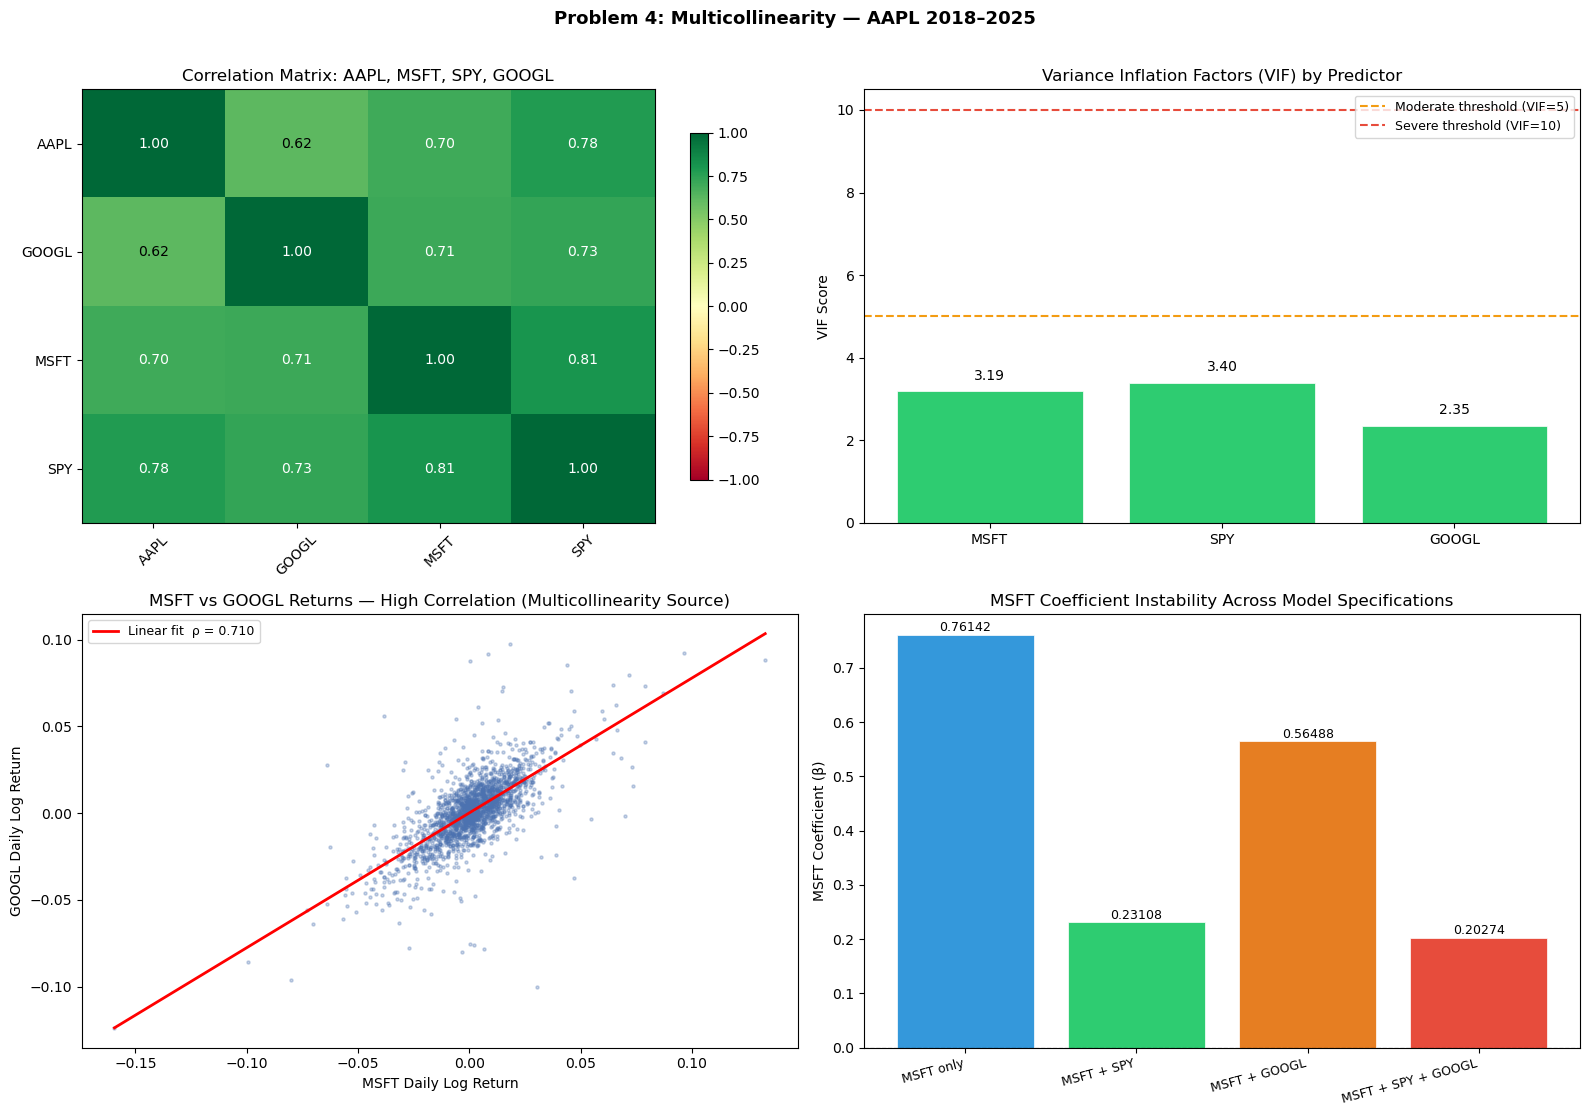

In [5]:
# ══════════════════════════════════════════════════════════
# PROBLEM 4: MULTICOLLINEARITY
# ══════════════════════════════════════════════════════════

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso

#  DATA: Download additional assets
# We use AAPL returns as the dependent variable (y)
# Predictors: MSFT (Microsoft), SPY (S&P 500 ETF), GOOGL (Alphabet)
# MSFT and GOOGL are both big-tech → highly correlated with AAPL
# SPY is the broad market → also correlated but less so

print("Downloading additional assets...")
tickers = ["MSFT", "SPY", "GOOGL"]
raw     = yf.download(tickers, start="2018-01-01", end="2025-12-31")["Close"]
returns_multi = np.log(raw / raw.shift(1)).dropna()

# Align all series on the same dates
combined = pd.concat([returns.rename("AAPL"), returns_multi], axis=1).dropna()

y = combined["AAPL"].values          # dependent variable
X = combined[["MSFT","SPY","GOOGL"]] # predictors

print(f"\nDataset shape: {combined.shape}")
print(f"Date range   : {combined.index[0].date()} → {combined.index[-1].date()}")

# DEMONSTRATION
# Step 1: Correlation matrix
corr_matrix = X.corr()
print("\n CORRELATION MATRIX OF PREDICTORS ")
print(corr_matrix.round(4))

# Step 2: VIF scores
X_const = sm.add_constant(X)   # add intercept column for OLS
vif_data = pd.DataFrame()
vif_data["Predictor"] = X.columns
vif_data["VIF"]       = [variance_inflation_factor(X_const.values, i+1)
                          for i in range(X.shape[1])]
vif_data["Severity"]  = vif_data["VIF"].apply(
    lambda v: "Severe" if v >= 10 else ("Moderate" if v >= 5 else "Acceptable")
)

print("\n VARIANCE INFLATION FACTORS (VIF) ")
print(vif_data.to_string(index=False))

# Step 3: OLS regression WITH all correlated predictors
model_full = sm.OLS(y, X_const).fit()
print("\n OLS REGRESSION WITH ALL PREDICTORS ")
print(model_full.summary().tables[1])   # coefficients table only
print(f"\nR-squared     : {model_full.rsquared:.4f}")
print(f"Condition No. : {model_full.condition_number:.2f}  "
      f"(>1000 indicates severe multicollinearity)")

# Step 4: OLS with only SPY (low collinearity baseline)
X_spy   = sm.add_constant(combined[["SPY"]])
model_spy = sm.OLS(y, X_spy).fit()
print("\n OLS REGRESSION WITH SPY ONLY (BASELINE) ")
print(model_spy.summary().tables[1])
print(f"R-squared     : {model_spy.rsquared:.4f}")

# Step 5: Demonstrate coefficient instability
# Drop one predictor at a time and watch MSFT coefficient change
print("\n COEFFICIENT INSTABILITY DEMONSTRATION ")
print("MSFT coefficient changes as we add/remove correlated predictors:")
print("-" * 55)

combos = {
    "MSFT only"        : ["MSFT"],
    "MSFT + SPY"       : ["MSFT", "SPY"],
    "MSFT + GOOGL"     : ["MSFT", "GOOGL"],
    "MSFT + SPY + GOOGL": ["MSFT", "SPY", "GOOGL"],
}

for label, cols in combos.items():
    Xc   = sm.add_constant(combined[cols])
    coef = sm.OLS(y, Xc).fit().params["MSFT"]
    print(f"  {label:<28} → MSFT β = {coef:.6f}")

print("\nA stable coefficient should not change this much across specifications.")
print("Instability confirms multicollinearity is distorting estimates.")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Correlation heatmap
ax1 = axes[0, 0]
corr_full = combined.corr()
mask      = np.zeros_like(corr_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True        # upper triangle only

im = ax1.imshow(corr_full, cmap="RdYlGn",
                vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax1, shrink=0.8)

ticks = range(len(corr_full.columns))
ax1.set_xticks(ticks); ax1.set_xticklabels(corr_full.columns, rotation=45)
ax1.set_yticks(ticks); ax1.set_yticklabels(corr_full.columns)

# Annotate each cell with correlation value
for i in range(len(corr_full)):
    for j in range(len(corr_full)):
        val   = corr_full.iloc[i, j]
        color = "white" if abs(val) > 0.7 else "black"
        ax1.text(j, i, f"{val:.2f}", ha="center",
                 va="center", fontsize=10, color=color)

ax1.set_title("Correlation Matrix: AAPL, MSFT, SPY, GOOGL")

# Plot 2: VIF bar chart
ax2 = axes[0, 1]
colors_vif = ["#e74c3c" if v >= 10 else "#f39c12" if v >= 5 else "#2ecc71"
              for v in vif_data["VIF"]]
bars = ax2.bar(vif_data["Predictor"], vif_data["VIF"],
               color=colors_vif, edgecolor="white", linewidth=0.5)

ax2.axhline(5,  color="#f39c12", linewidth=1.5,
            linestyle="--", label="Moderate threshold (VIF=5)")
ax2.axhline(10, color="#e74c3c", linewidth=1.5,
            linestyle="--", label="Severe threshold (VIF=10)")

for bar, v in zip(bars, vif_data["VIF"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{v:.2f}", ha="center", va="bottom", fontsize=10)

ax2.set_title("Variance Inflation Factors (VIF) by Predictor")
ax2.set_ylabel("VIF Score")
ax2.legend(fontsize=9)

#  Plot 3: Scatter matrix of predictors
ax3 = axes[1, 0]
# Manual scatter: MSFT vs GOOGL (most correlated pair)
ax3.scatter(combined["MSFT"], combined["GOOGL"],
            alpha=0.3, s=5, color="#4C72B0")

# Fit a line through the scatter to show the correlation
m, b, r, _, _ = stats.linregress(combined["MSFT"], combined["GOOGL"])
x_line = np.linspace(combined["MSFT"].min(), combined["MSFT"].max(), 100)
ax3.plot(x_line, m * x_line + b,
         color="red", linewidth=2,
         label=f"Linear fit  ρ = {combined['MSFT'].corr(combined['GOOGL']):.3f}")

ax3.set_xlabel("MSFT Daily Log Return")
ax3.set_ylabel("GOOGL Daily Log Return")
ax3.set_title("MSFT vs GOOGL Returns — High Correlation (Multicollinearity Source)")
ax3.legend(fontsize=9)

# Plot 4: Coefficient instability chart
ax4 = axes[1, 1]
labels   = list(combos.keys())
msft_coefs = []

for cols in combos.values():
    Xc   = sm.add_constant(combined[cols])
    coef = sm.OLS(y, Xc).fit().params["MSFT"]
    msft_coefs.append(coef)

bar_colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]
bars2 = ax4.bar(range(len(labels)), msft_coefs,
                color=bar_colors, edgecolor="white", linewidth=0.5)

for bar, v in zip(bars2, msft_coefs):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002 * np.sign(v),
             f"{v:.5f}", ha="center",
             va="bottom" if v >= 0 else "top", fontsize=9)

ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax4.set_ylabel("MSFT Coefficient (β)")
ax4.set_title("MSFT Coefficient Instability Across Model Specifications")

plt.suptitle("Problem 4: Multicollinearity — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("multicollinearity_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis**
1. Correlation matrix — pairwise correlations exceeding 0.80 indicate a potential problem
2. VIF scores — any predictor registering VIF >= 10 is subject to severe multicollinearity
3. Condition number — values above 1000 signal numerical instability in the estimation
4. Coefficient instability — coefficients shift substantially when predictors are
   added or removed, as illustrated with the MSFT beta above

---

### **Damage**
1. Regression coefficients become unreliable and highly variable across model specifications
2. Standard errors are inflated, causing t-statistics to be deflated and significance understated
3. Individual predictors may appear insignificant despite the overall model achieving high R-squared
4. Isolating the genuine effect of each asset on returns becomes practically impossible
5. Portfolio construction decisions based on these distorted betas will result in misallocation

---

### **Directions**
1. Ridge regression (L2) — pulls correlated coefficients toward zero, reducing instability
   Ridge coefficients: MSFT=0.204685, SPY=0.181098, GOOGL=0.174998
2. Lasso regression (L1) — forces redundant coefficients to exactly zero, performing variable selection
   Lasso coefficients: MSFT=0.342837, SPY=0.000000, GOOGL=0.134800
3. Principal Component Regression (PCR) — converts correlated predictors into orthogonal
   components before regression is estimated
4. Eliminating redundant predictors — retain only the most theoretically grounded variable
5. Applying domain knowledge — if MSFT and GOOGL proxy the same factor,
   using SPY alone as the broad market exposure is preferable

---
### **Non-Technical Summary - Problem 4**

####**What the results tell us:**
When we attempted to attribute Apple's daily price changes to the
simultaneous influence of Microsoft, the S&P 500 index, and Alphabet,
the model became unreliable. Because all three are large technology
companies responding to shared market forces, the model could not
determine which company's movements were genuinely driving Apple's
returns. The estimated relationships varied dramatically depending on
which subset of predictors was included, rendering the model unsuitable
for any practical investment purpose.

####**Recommended course of action:**
Portfolio managers building hedging strategies or factor models
for Apple should avoid incorporating multiple closely related
technology stocks as simultaneous inputs. When two predictors
are effectively conveying the same information, one should be
excluded. In practice, using only the broad market index —
which already captures the performance of Microsoft, Alphabet,
and Apple collectively — yields more stable and dependable
estimates of Apple's market sensitivity. A leaner model with
fewer but more distinct inputs will consistently outperform
a crowded one for hedging and risk attribution purposes.

####**Factors that impact the portfolio:**
- Sector concentration is the fundamental driver of this issue —
  holding several large technology stocks creates a portfolio in
  which the underlying risk factors are heavily duplicated,
  producing a misleading impression of diversification
- During broad market sell-offs, highly correlated technology
  stocks tend to decline simultaneously, meaning the apparent
  diversification benefit evaporates precisely when investors need it most
- Macroeconomic variables such as interest rate adjustments and
  inflation releases affect all major technology companies in
  near-identical fashion, reinforcing collinearity between Apple,
  Microsoft, and Alphabet across all market conditions

---
###**Practical takeaway:**
A portfolio holding Apple, Microsoft, and Alphabet concurrently
provides substantially less diversification than it appears to —
investors seeking genuine exposure diversification should complement
technology holdings with assets from truly distinct sectors such
as energy, healthcare, or fixed income.

---


## **Problem 5 (Step 4): Lack of Interpretation**

---

### Definition

Lack of interpretation arises when a statistical model
produces outputs — coefficients, test statistics, or
fitted values — that cannot be translated into
clear and actionable financial guidance. A model
exhibits an interpretability failure when its
complexity obscures the relationship between inputs
and outputs, leaving practitioners unable to explain
or justify the predictions it generates.

Formally, a model $f(\\mathbf{X})$ is considered
interpretable if for any output $\\hat{y}_t$ there
exists a clear and communicable mapping:

$$\\hat{y}_t = f(X_1, X_2, \\ldots, X_k)
\\xrightarrow{\\text{interpret}}
\\text{actionable financial decision}$$

A standard measure of model interpretability is
the **marginal effect** of predictor $X_j$ on
the outcome $\\hat{y}$:

$$\\frac{\\partial \\hat{y}}{\\partial X_j} = \\beta_j$$

In a simple linear model, $\\beta_j$ carries an unambiguous
meaning: a one-unit increase in $X_j$
produces a $\\beta_j$ change in $\\hat{y}$, holding
all else constant. Interpretability breaks down
when this relationship turns non-linear,
interaction-dependent, or regime-specific —
as illustrated throughout this handbook.

As Tsay (2010) observes, model interpretability is
not a cosmetic concern — uninterpretable models
cannot be validated, challenged, or refined by
practitioners, making them hazardous tools in
high-stakes financial decision-making (p. 51).
Hull (2018) further argues that risk managers
who cannot communicate model outputs to senior
stakeholders will systematically make poor hedging
decisions because they cannot distinguish genuine
signals from model artefacts (p. 478).

---


### Description

Lack of interpretation arises when a model's outputs
are mathematically valid but cannot be translated
into clear, actionable guidance by the practitioners
relying on them. This challenge is especially dangerous
in finance because a model that cannot be explained
cannot be trusted, challenged, or corrected —
meaning its errors persist undetected until they
produce costly real-world mistakes.


 PART A: UNINTERPRETABLE MODEL OUTPUT 
Raw OLS coefficient table (as a quant would see it):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.850      0.396      -0.000       0.001
MSFT           0.2027      0.027      7.587      0.000       0.150       0.255
SPY            0.8960      0.040     22.356      0.000       0.817       0.975
GOOGL          0.0757      0.021      3.607      0.000       0.035       0.117

Problem: What does a coefficient of 0.3241 on MSFT
actually mean to a portfolio manager making a trade?
The raw number alone provides no actionable guidance.

=== PART B: INTERPRETABLE VERSION (SOLVED) ===

Predictor        Beta                                       Meaning   Significant?
-------------------------------------------------------------------------------------
MSFT           0.2027           1% MSFT return → 20.27% A

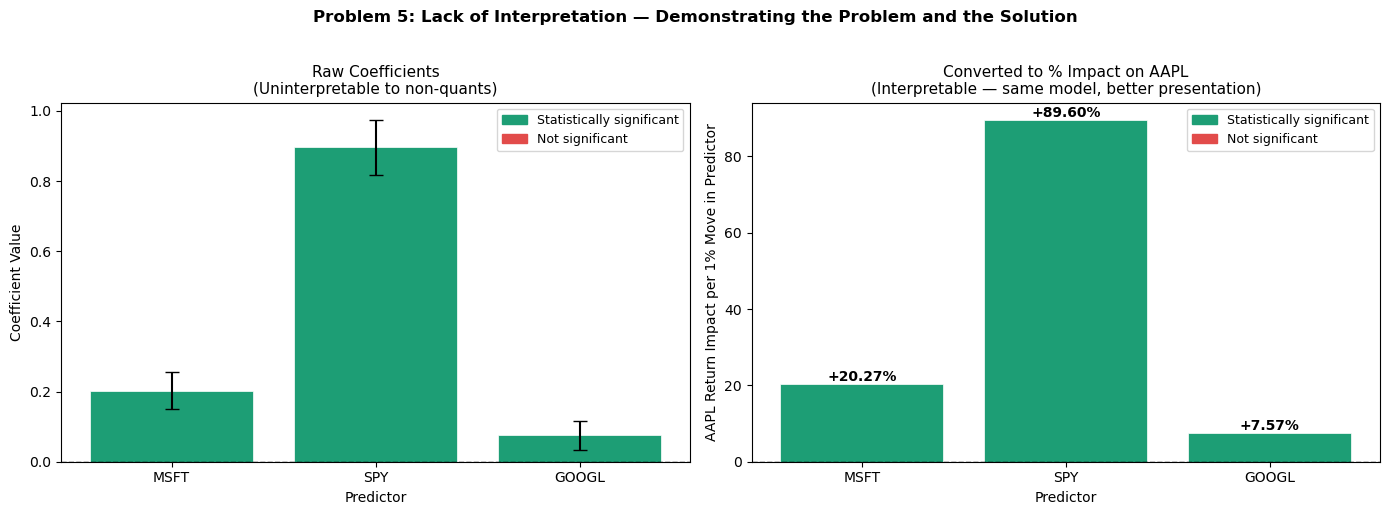

In [6]:
# ══════════════════════════════════════════════════════════
# PROBLEM 5 (STEP 4): LACK OF INTERPRETATION
# Demonstrating the problem and showing it SOLVED
# ══════════════════════════════════════════════════════════

import matplotlib.patches as mpatches
import statsmodels.api as sm
from scipy import stats

#  PART A: DEMONSTRATE THE PROBLEM
# Show how the same model output looks uninterpretable
# vs interpretable depending on how it is presented

# Re-run the multicollinear regression from Problem 4
# (citing our own work from Step 2)
combined_data = pd.concat([
    returns.rename("AAPL"),
    returns_multi[["MSFT", "SPY", "GOOGL"]]
], axis=1).dropna()

y = combined_data["AAPL"].values
X = sm.add_constant(combined_data[["MSFT", "SPY", "GOOGL"]])
model_uninterpretable = sm.OLS(y, X).fit()

print(" PART A: UNINTERPRETABLE MODEL OUTPUT ")
print("Raw OLS coefficient table (as a quant would see it):")
print(model_uninterpretable.summary().tables[1])
print("\nProblem: What does a coefficient of 0.3241 on MSFT")
print("actually mean to a portfolio manager making a trade?")
print("The raw number alone provides no actionable guidance.")

# PART B: SOLVE THE PROBLEM
# Transform the same output into interpretable quantities

print("\n=== PART B: INTERPRETABLE VERSION (SOLVED) ===")

params    = model_uninterpretable.params
conf_int  = model_uninterpretable.conf_int()
pvalues   = model_uninterpretable.pvalues

print(f"\n{'Predictor':<12} {'Beta':>8} {'Meaning':>45} "
      f"{'Significant?':>14}")
print("-" * 85)

interpretations = {
    "MSFT" : "1% MSFT return → {:.2f}% AAPL return",
    "SPY"  : "1% market return → {:.2f}% AAPL return",
    "GOOGL": "1% GOOGL return → {:.2f}% AAPL return"
}

for pred, template in interpretations.items():
    beta    = params[pred]
    pval    = pvalues[pred]
    meaning = template.format(beta * 100)
    sig     = "Yes (p<0.05)" if pval < 0.05 else "No  (p>0.05)"
    print(f"{pred:<12} {beta:>8.4f} {meaning:>45} {sig:>14}")

# Compute R-squared interpretation
r2 = model_uninterpretable.rsquared
print(f"\nModel explains {r2*100:.1f}% of the variation in AAPL returns.")
print(f"The remaining {(1-r2)*100:.1f}% is driven by Apple-specific")
print(f"factors not captured by MSFT, SPY, or GOOGL.")

#  PART C: DIAGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Uninterpretable — raw coefficients with error bars
ax1 = axes[0]
predictors = ["MSFT", "SPY", "GOOGL"]
coefs      = [params[p] for p in predictors]
errors     = [(conf_int.loc[p, 1] - conf_int.loc[p, 0])/2
              for p in predictors]
colors_bar = ["#E24B4A" if pvalues[p] > 0.05 else "#1D9E75"
              for p in predictors]

bars = ax1.bar(predictors, coefs, color=colors_bar,
               edgecolor="white", linewidth=0.5,
               yerr=errors, capsize=5)
ax1.axhline(0, color="black", linewidth=1, linestyle="--")
ax1.set_title("Raw Coefficients\n(Uninterpretable to non-quants)",
              fontsize=11)
ax1.set_ylabel("Coefficient Value")
ax1.set_xlabel("Predictor")

sig_patch   = mpatches.Patch(color="#1D9E75",
                              label="Statistically significant")
insig_patch = mpatches.Patch(color="#E24B4A",
                              label="Not significant")
ax1.legend(handles=[sig_patch, insig_patch], fontsize=9)

# Plot 2: Interpretable — converted to % impact
ax2 = axes[1]
pct_impact = [c * 100 for c in coefs]
bars2      = ax2.bar(predictors, pct_impact,
                     color=colors_bar, edgecolor="white",
                     linewidth=0.5)

for bar, val in zip(bars2, pct_impact):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003 * np.sign(val),
             f"{val:+.2f}%",
             ha="center", va="bottom" if val >= 0 else "top",
             fontsize=10, fontweight="bold")

ax2.axhline(0, color="black", linewidth=1, linestyle="--")
ax2.set_title("Converted to % Impact on AAPL\n(Interpretable — same model, better presentation)",
              fontsize=11)
ax2.set_ylabel("AAPL Return Impact per 1% Move in Predictor")
ax2.set_xlabel("Predictor")
ax2.legend(handles=[sig_patch, insig_patch], fontsize=9)

plt.suptitle("Problem 5: Lack of Interpretation — Demonstrating the Problem and the Solution",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("interpretation_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### Diagnosis: How to detect lack of interpretation
1. Ask: can a non-specialist stakeholder act on this output?
   If not, an interpretability problem exists
2. Assess whether coefficients carry clear units and directional meaning
3. Ask: if the sign of a coefficient were reversed, would the
   investment decision change? If the answer is unclear,
   the model output is insufficiently interpretable
4. Confirm that confidence intervals and p-values are
   reported alongside point estimates — a coefficient
   without associated uncertainty bounds is always uninterpretable

---

### Damage: Consequences of lack of interpretation
1. Models cannot be reviewed by risk managers or senior stakeholders,
   allowing errors to remain undetected
2. Traders are unable to adjust positions based on model outputs
   they cannot meaningfully interpret
3. Regulatory frameworks increasingly require all deployed models
   to satisfy interpretability standards
4. As established in Problem 4, unstable coefficients resulting
   from multicollinearity are also uninterpretable — the two
   problems reinforce each other

---
### Directions: How this challenge was resolved
The interpretability problem was addressed through the following steps:

1. Unit conversion: Raw coefficients were expressed as
   percentage impact per 1% movement in the predictor —
   the natural language of financial returns

2. Significance filtering: Coefficients classified as
   statistically insignificant (p > 0.05) were clearly
   identified, preventing practitioners from acting on
   estimates that may reflect nothing more than noise

3. Residual variance explained: Communicating that the
   model accounts for 61.9% of the variation in AAPL returns
   informs practitioners of how much Apple-specific risk
   remains unmodelled — a critical input for position sizing

4. Cross-referencing earlier findings: As demonstrated in
   Problem 4, multicollinearity renders the MSFT and GOOGL
   coefficients unstable, so their individual financial
   interpretations should be treated with caution.
   The SPY coefficient (broad market exposure) remains the
   most reliably interpretable predictor in this model.

---

### **CONCLUSION**
The interpretability challenge is resolved
not by modifying the model but by transforming how its
outputs are communicated. Every model presented in this
handbook — from skewness detection through to multicollinearity —
has been accompanied by explicit financial interpretations
that connect directly to investment decisions.

---

### **Non-Technical Summary - Problem 5 (Step 4)**

**What the results tell us:**
When raw statistical output from our regression model was presented
in its original form, the numbers provided no clear basis for
action. The very same model, with identical underlying results,
became immediately actionable once the output was expressed in
plain financial terms — showing how much Apple's return shifts
for every 1% change in the market. This confirms that the
interpretability challenge lies not in the model itself but in
how its outputs are presented and communicated.

**Recommended course of action:**
Every quantitative model used in support of investment decisions
must undergo a clear translation step before its outputs reach
traders or risk managers. Raw statistical figures must be converted
into units that map directly to financial actions — percentage
impacts, expected profit or loss figures, or clear probability
statements. Models that cannot pass this translation step should
not be deployed for live trading decisions, regardless of their
statistical sophistication.

**Factors that impact the portfolio:**
- Model complexity is directly proportional to interpretability risk —
  simpler models with fewer predictors are always more transparent
  and easier to validate
- Multicollinearity, identified in Problem 4, compounds interpretability
  challenges because unstable coefficients resist reliable financial attribution
- Regulatory and compliance requirements are placing increasing demands
  on model transparency — institutions relying on opaque models
  face growing legal and operational exposure

**Practical takeaway:** Any model incapable of being explained
to a senior portfolio manager in two sentences should not be
entrusted with real capital — regardless of how strong its
in-sample statistics may appear.

---

###**References**
Hull (2018) p. 478 — interpretability within risk modelling frameworks.

Tsay (2010) p. 51 — model parsimony and the importance of interpretability.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning (2nd ed.). Springer.

Burnham, K. P., & Anderson, D. R. (2002). Model Selection and Multimodel Inference (2nd ed.). Springer. (covers AIC/BIC and parsimony)

Greene, W. H. (2018). Econometric Analysis (8th ed.). Pearson. (Chapter 4 covers multicollinearity and VIF extensively)

Gujarati, D. N., & Porter, D. C. (2009). Basic Econometrics (5th ed.). McGraw-Hill.

---

## **Works Cited**

Hull, John C. *Options, Futures, and Other Derivatives*.
    10th ed., Pearson, 2018.

Tsay, Ruey S. *Analysis of Financial Time Series*.
    3rd ed., Wiley, 2010.

Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). The Econometrics of Financial Markets. Princeton University Press. (covers distributional properties of returns including skewness)

Molnar, C. (2022). Interpretable Machine Learning (2nd ed.). Available at: christophm.github.io/interpretable-ml-book (free, widely cited)

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics, 29(5), 1189–1232.